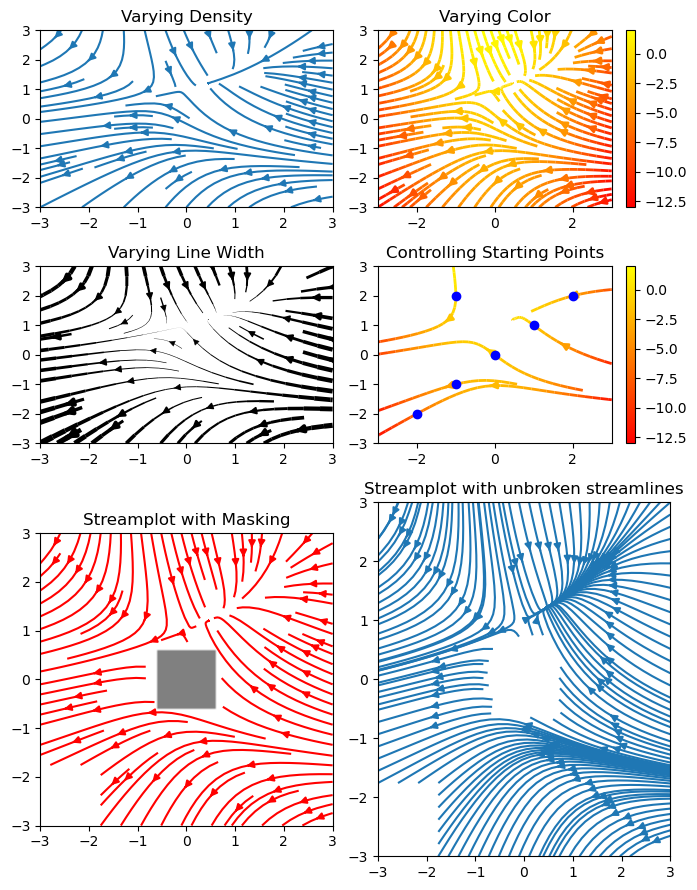

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义矢量场的范围：从 -w 到 w
w = 3
# 创建二维网格：100x100 的网格点
# mgrid 生成密集网格，100j 表示 100 个步长（包含端点）
Y, X = np.mgrid[-w:w:100j, -w:w:100j]

# 定义矢量场的两个分量 U (x方向) 和 V (y方向)
# 这是一个经典的二维矢量场示例
U = -1 - X**2 + Y
V = 1 + X - Y**2

# 计算每个点的速度大小（用于后续设置线宽或颜色映射）
speed = np.sqrt(U**2 + V**2)

# 创建 3 行 2 列的子图布局，总尺寸为 7x9 英寸
# fig 是整个图形的“画布窗口”
# axs 是6个“绘图区域”的集合(二位数组)
fig, axs = plt.subplots(3, 2, figsize=(7, 9), height_ratios=[1, 1, 2])
axs = axs.flat  # 将二维子图数组展平为一维，方便遍历

# ----- 子图 1：改变流线密度 -----
# density=[0.5, 1] 分别控制 x 和 y 方向的流线密度
axs[0].streamplot(X, Y, U, V, density=[0.5, 1])
axs[0].set_title('Varying Density')

# ----- 子图 2：沿流线改变颜色 -----
# color=U 表示根据 U 分量的大小给流线上色
# cmap='autumn' 指定颜色映射为秋季色调
strm = axs[1].streamplot(X, Y, U, V, color=U, linewidth=2, cmap='autumn')
fig.colorbar(strm.lines)  # 添加颜色条
axs[1].set_title('Varying Color')

# ----- 子图 3：沿流线改变线宽 -----
# 线宽与速度大小成正比：速度越大，线条越粗
lw = 5 * speed / speed.max()
axs[2].streamplot(X, Y, U, V, density=0.6, color='k', linewidth=lw)
axs[2].set_title('Varying Line Width')

# ----- 子图 4：控制流线的起始点 -----
# seed_points 定义流线的起始位置：第一行是 x 坐标，第二行是 y 坐标
seed_points = np.array([[-2, -1, 0, 1, 2, -1], [-2, -1, 0, 1, 2, 2]])
# start_points 需要传入 (N, 2) 形状的数组，所以转置 seed_points
strm = axs[3].streamplot(X, Y, U, V, color=U, linewidth=2,
                         cmap='autumn', start_points=seed_points.T)
fig.colorbar(strm.lines)
axs[3].set_title('Controlling Starting Points')
# 用蓝色圆点标记起始点位置
axs[3].plot(seed_points[0], seed_points[1], 'bo')
axs[3].set(xlim=(-w, w), ylim=(-w, w))

# ----- 子图 5：掩码（mask）和 NaN 处理 -----
# 创建一个掩码，屏蔽中间 20x20 的区域
mask = np.zeros(U.shape, dtype=bool)
mask[40:60, 40:60] = True
# 在左上角 20x20 区域设置 NaN（流线会跳过 NaN 区域）
U[:20, :20] = np.nan
# 将 U 转换为掩码数组，被掩码覆盖的位置不绘制流线
U = np.ma.array(U, mask=mask)

axs[4].streamplot(X, Y, U, V, color='r')
axs[4].set_title('Streamplot with Masking')
# 用半透明灰色显示掩码区域
axs[4].imshow(~mask, extent=(-w, w, -w, w), alpha=0.5, cmap='gray', aspect='auto')
axs[4].set_aspect('equal')

# ----- 子图 6：禁用流线断裂 -----
# broken_streamlines=False 确保流线不会因为超出网格单元限制而断裂
axs[5].streamplot(X, Y, U, V, broken_streamlines=False)
axs[5].set_title('Streamplot with unbroken streamlines')

plt.tight_layout()  # 自动调整子图间距
plt.show()